<a href="https://colab.research.google.com/github/renzoardiles-pixel/Colab-UNI/blob/main/M%C3%B3dulo_3_Lenguaje_de_Manipulaci%C3%B3n_de_Datos_(DML)_INSERT%2C_UPDATE%2C_DELETE_y_Transacciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

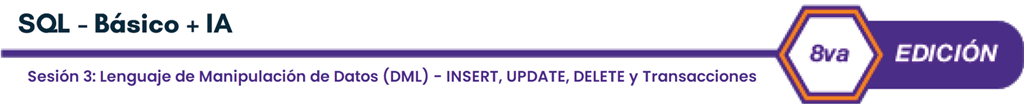

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">CREACIÓN DE TABLAS</font>**

</td>
</tr>
</table>

La creación de tablas en SQL Server 2025 sigue una estructura y sintaxis que son parte del lenguaje de consulta estructurado (SQL).

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
CREATE TABLE esquema.nombre_tabla (
    columna1 tipo_dato [opciones],
    columna2 tipo_dato [opciones],
    ...
);
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Creación de la tabla de roles sin reglas</font>**

</td>
</tr>
</table>



```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in INT,
	nom_rol_nvc NVARCHAR(50) NOT NULL
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (8, 'Ventas');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (2, 'Almacén');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (5, 'Facturación');
GO
SELECT * FROM Personal.rol;
GO
```



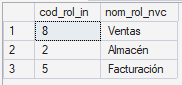

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Table Scan</font>**

</td>
</tr>
</table>

Un Table Scan en SQL Server 2025 es una técnica utilizada por el motor de base de datos para leer los datos de una tabla completa.

Si bien puede ser necesario en ciertas situaciones, en muchas ocasiones es menos eficiente que otros métodos, como los Index Seek.

Un Table Scan se produce cuando SQL Server tiene que recorrer cada fila en la tabla para encontrar las que cumplen con las condiciones de la consulta. Esto es comúnmente necesario cuando:
>* No hay un índice que pueda ser utilizado para acelerar la búsqueda.
>* La consulta requiere acceder a una gran parte de la tabla.
>* Se están utilizando ciertas operaciones, como SELECT *, que requieren todos los datos.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

#### **<font color="#FFFFFF">¿Cuándo ocurre un Table Scan?</font>**

</td>
</tr>
</table>

>* **Sin índices**: Cuando no hay índices disponibles que cubran la consulta, el motor de SQL Server debe escanear toda la tabla para obtener los resultados.
>* **Consultas que solicitan muchas filas**: Si la consulta devuelve una gran cantidad de filas, a veces puede ser más eficiente escanear toda la tabla en lugar de buscar mediante un índice.
>* **Condiciones de filtro**: Cuando las condiciones de filtro no pueden ser satisfactoriamente aplicadas a través de índices, se recurre a un Table Scan.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

#### **<font color="#FFFFFF">Análisis de Rendimiento</font>**

</td>
</tr>
</table>

>* **Costo**: Un Table Scan puede ser costoso en términos de rendimiento, especialmente en tablas grandes, ya que implica leer todas las filas de la tabla.
>* **Uso de Recursos**: Requiere más recursos de CPU y I/O (entrada/salida) en comparación con operaciones que utilizan índices.
>* **Alternativas**: En muchos casos, puedes mejorar el rendimiento de las consultas utilizando índices bien diseñados, que pueden ayudar a SQL Server a acceder a los datos de manera más rápida y eficiente.



```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in INT,
	nom_rol_nvc NVARCHAR(50) NOT NULL
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (8, 'Ventas');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (2, 'Almacén');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (5, 'Facturación');
GO
SET SHOWPLAN_ALL ON;
GO
SELECT * FROM Personal.rol;
GO
SET SHOWPLAN_ALL OFF;
GO

```



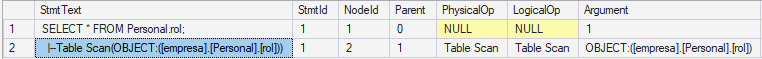

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Clustered Index Scan</font>**

</td>
</tr>
</table>

Un Clustered Index Scan en SQL Server 2025 es una operación que se lleva a cabo cuando el motor de base de datos necesita acceder a filas en una tabla que tiene un índice agrupado (clustered index).

Aunque este tipo de acceso puede ser más eficiente que un Table Scan, aún puede ser costoso en términos de recursos, especialmente si se requiere acceder a muchas filas.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">¿Qué es un Clustered Index?</font>**

</td>
</tr>
</table>

Un índice agrupado organiza físicamente los datos de la tabla en disco según el orden del índice.

Cada tabla solo puede tener un índice agrupado porque los datos deben estar almacenados en un solo orden. Este índice utiliza la clave del índice para determinar cómo se almacenan los registros.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">¿Qué es un Clustered Index Scan?</font>**

</td>
</tr>
</table>

Un Clustered Index Scan se produce cuando SQL Server utiliza un índice agrupado para leer la información de la tabla.

A diferencia de un Table Scan, que lee todos los datos independientemente de su orden, un Indexed Scan puede beneficiarse del ordenamiento definido por el índice.

Sin embargo, sigue escaneando múltiples filas y puede ser menos eficiente si se necesita acceder a un gran volumen de datos.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">¿Cuándo Ocurre un Clustered Index Scan?</font>**

</td>
</tr>
</table>

>* **Consultas sin un filtro efectivo**: Si la consulta no tiene condiciones de filtro que limiten significativamente el número de filas requeridas.
>* **Acceso a rangos de datos**: Cuando se necesitan acceder a un rango de datos que abarca múltiples páginas en el índice.
>* **Uso de SELECT `*`**: Si se requiere recuperar todas las columnas de la tabla, lo que puede resultar en la necesidad de escanear múltiples filas.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Análisis de Rendimiento</font>**

</td>
</tr>
</table>

>* **Costo**: Aunque más eficiente que un Table Scan, un Clustered Index Scan aún puede ser costoso si la tabla contiene muchas filas, ya que implica leer una gran cantidad de datos.
>* **Uso de Recursos**: Requiere más I/O y procesamiento de CPU en comparación con un Index Seek, que accede de manera más directa a las filas necesarias.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Clave Primaria - Primary Key(PK)</font>**

</td>
</tr>
</table>

Clave Primaria - Clave Principal - Llave Primaria  - Llave Principal

Una clave primaria es un conjunto de una o más columnas que son utilizadas para identificar de manera única cada registro en una tabla.

No puede haber dos filas en una tabla que tengan el mismo valor en la clave primaria, lo que asegura que cada fila pueda ser referenciada de forma única.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

#### **<font color="#FFFFFF">Características de una Clave Primaria</font>**

</td>
</tr>
</table>

>* **Unicidad**: Cada valor en la clave primaria debe ser único. No puede haber duplicados en ninguna de las filas.
>* **No Nulo**: Las columnas que forman parte de la clave primaria no pueden contener valores nulos. Esto asegura que cada fila esté identificada de manera válida.
>* **Inmutable**: Aunque no es una restricción estricta, se recomienda que los valores en la clave primaria no cambien. Esto es importante para mantener la integridad referencial.
>* **Índice**: SQL Server crea automáticamente un índice único para la clave primaria, lo que mejora el rendimiento de las consultas que utilizan esta clave.

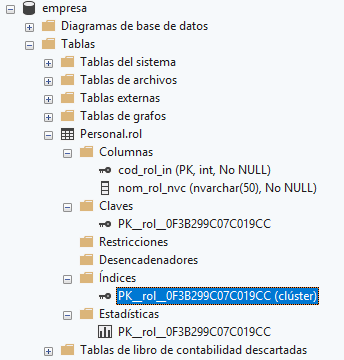



```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in INT
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED NOT NULL,
	nom_rol_nvc NVARCHAR(50) NOT NULL
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (8, 'Ventas');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (2, 'Almacén');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (5, 'Facturación');
GO
--SET SHOWPLAN_ALL ON;
GO
SELECT * FROM Personal.rol;
GO
--SET SHOWPLAN_ALL OFF;
GO
```





```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT				NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,

	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in)
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (8, 'Ventas');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (2, 'Almacén');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (5, 'Facturación');
GO
--SET SHOWPLAN_ALL ON;
GO
SELECT * FROM Personal.rol;
GO
--SET SHOWPLAN_ALL OFF;
GO

```





```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT				NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,

);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (8, 'Ventas');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (2, 'Almacén');
INSERT INTO Personal.rol (cod_rol_in, nom_rol_nvc) VALUES (5, 'Facturación');
GO
ALTER TABLE Personal.rol
ADD CONSTRAINT pk_personal_rol_cod_rol_in
PRIMARY KEY CLUSTERED(cod_rol_in)
GO
SELECT * FROM Personal.rol;
GO
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">IDENTITY</font>**

</td>
</tr>
</table>

El atributo IDENTITY en SQL Server se utiliza para generar valores únicos para una columna de forma automática, comúnmente en columnas que actúan como claves primarias.

Este mecanismo es particularmente útil para crear identificadores únicos sin necesidad de especificar manualmente estos valores cada vez que se inserta un nuevo registro en la tabla.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

#### **<font color="#FFFFFF">¿Qué es el IDENTITY?</font>**

</td>
</tr>
</table>

>* **Generación Automática**: Al definir una columna como IDENTITY, SQL Server se encarga de generar automáticamente un nuevo valor para esa columna cada vez que se inserta un registro.
>* **Incremento**: Los valores generados son números enteros que se incrementan en una cantidad específica cada vez que se añade una nueva fila.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

#### **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
IDENTITY(semilla, incremento)
```



>* **Semilla**: Es el valor inicial a partir del cual comenzará a contar. Por defecto, empieza en 1.
>* **Incremento**: Es el valor que se añade al último valor generado. Por defecto, es 1.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

#### **<font color="#FFFFFF">Ejemplo</font>**

</td>
</tr>
</table>



```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in) NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Ventas');
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Almacén');
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Facturación');
GO
SELECT * FROM Personal.rol;
GO
```





```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY(10001, 1)
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in) NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Ventas');
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Almacén');
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Facturación');
GO
SELECT * FROM Personal.rol;
GO

```



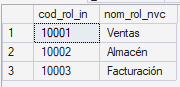

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">INSERT INTO</font>**

</td>
</tr>
</table>

El comando INSERT INTO en SQL Server se utiliza para agregar nuevas filas (registros) a una tabla en una base de datos. Es fundamental para la manipulación de datos y permite insertar uno o varios registros en una sola operación.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
INSERT INTO esquema.nombre_tabla (columna1, columna2, columna3)
VALUES (valor1, valor2, valor3);
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Ejemplos</font>**

</td>
</tr>
</table>



```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in) NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Ventas');
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Almacén');
INSERT INTO Personal.rol (nom_rol_nvc) VALUES ('Facturación');
GO
SELECT * FROM Personal.rol;
GO

```





```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in) NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc) VALUES
('Ventas'),
('Almacén'),
('Facturación');
GO
SELECT * FROM Personal.rol;
GO

```





```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in) NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc)
SELECT name
FROM sys.schemas
WHERE principal_id != schema_id
ORDER BY name;
GO
SELECT * FROM Personal.rol;
GO
```



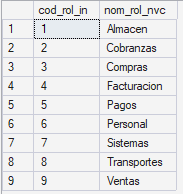

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Clave Alterna - Alternate Key (AK)</font>**

</td>
</tr>
</table>

La clave alterna (Alternate Key o AK) en SQL Server es una clave única que no es la clave primaria de la tabla pero que todavía se utiliza para identificar de manera única un registro.

Las claves alternas son importantes para garantizar la integridad de los datos y permitir búsquedas eficientes sobre columnas que no son designadas como claves primarias.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Características de la Clave Alterna (AK)</font>**

</td>
</tr>
</table>

>* **Unicidad**: Al igual que la clave primaria, una clave alterna garantiza que los valores en la columna o columnas designadas sean únicos dentro de la tabla.
>* **Puede contener un NULL**: A diferencia de la clave primaria, que no puede contener valores nulos, las claves alternas pueden tener uno valor nulo, dependiendo de las restricciones definidas.
>* **Índice Único**: SQL Server crea automáticamente un índice único en la clave alterna para optimizar la búsqueda y el acceso a los datos.
>* **No es la Clave Principal**: La clave alterna permite acceder a los registros de forma única, pero no se utiliza como la clave principal para las relaciones en la tabla.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Ejemplos</font>**

</td>
</tr>
</table>

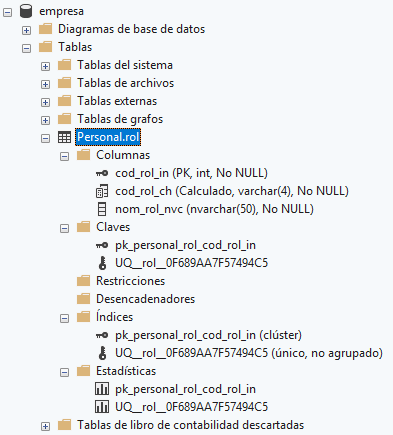



```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in) NOT NULL,
	cod_rol_ch		AS 'R'+RIGHT('000' + LTRIM(cod_rol_in), 3) PERSISTED
	--CONSTRAINT ak_personal_rol_cod_rol_ch
	UNIQUE NONCLUSTERED NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc)
SELECT name
FROM sys.schemas
WHERE principal_id != schema_id
ORDER BY name;
GO
SELECT * FROM Personal.rol;
GO

```





```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in) NOT NULL,
	cod_rol_ch		AS 'R'+RIGHT('000' + LTRIM(cod_rol_in), 3) PERSISTED
	CONSTRAINT ak_personal_rol_cod_rol_ch
	UNIQUE NONCLUSTERED NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc)
SELECT name
FROM sys.schemas
WHERE principal_id != schema_id
ORDER BY name;
GO
SELECT * FROM Personal.rol;
GO

```



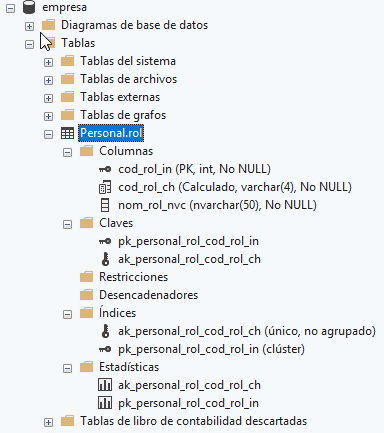



```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY NOT NULL,
	cod_rol_ch		AS 'R'+RIGHT('000' + LTRIM(cod_rol_in), 3) PERSISTED NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,

	-- Clave Primaria y Unica
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in),

	-- Clave Alternativa y Unica
	CONSTRAINT ak_personal_rol_cod_rol_ch
	UNIQUE NONCLUSTERED(cod_rol_ch)
);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc)
SELECT name
FROM sys.schemas
WHERE principal_id != schema_id
ORDER BY name;
GO
SELECT * FROM Personal.rol;
GO

```





```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		INT IDENTITY NOT NULL,
	cod_rol_ch		AS 'R'+RIGHT('000' + LTRIM(cod_rol_in), 3) PERSISTED NOT NULL,
	nom_rol_nvc		NVARCHAR(50)	NOT NULL,

	-- Clave Primaria y Unica
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in),

);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc)
SELECT name
FROM sys.schemas
WHERE principal_id != schema_id
ORDER BY name;
GO
ALTER TABLE Personal.rol
ADD CONSTRAINT ak_personal_rol_cod_rol_ch
UNIQUE NONCLUSTERED(cod_rol_ch);
GO
SELECT * FROM Personal.rol;
GO

```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Ejemplo de Creación de una tabla usando los tipos de datos creados por el usuario</font>**

</td>
</tr>
</table>



```
USE empresa;
GO
-- Crear la tabla 'rol' si no existe
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'rol'
)
DROP TABLE Personal.rol;
GO
CREATE TABLE Personal.rol
(
	cod_rol_in		td_codigo IDENTITY NOT NULL,
	cod_rol_ch		AS 'R'+RIGHT('000' + LTRIM(cod_rol_in), 3) PERSISTED NOT NULL,
	nom_rol_nvc		td_nombre	NOT NULL,

	-- Clave Primaria y Unica
	CONSTRAINT pk_personal_rol_cod_rol_in
	PRIMARY KEY CLUSTERED(cod_rol_in),

);
GO
-- Insertar datos en la tabla 'rol'
INSERT INTO Personal.rol (nom_rol_nvc)
SELECT name
FROM sys.schemas
WHERE principal_id != schema_id
ORDER BY name;
GO
ALTER TABLE Personal.rol
ADD CONSTRAINT ak_personal_rol_cod_rol_ch
UNIQUE NONCLUSTERED(cod_rol_ch);
GO
SELECT * FROM Personal.rol;
GO

```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Clave Foránea - Clave Externa - - Foreign Key (FK)</font>**

</td>
</tr>
</table>

Una clave foránea (Foreign Key o FK) en SQL Server es una restricción que establece una relación entre dos tablas.

Se utiliza para garantizar la integridad referencial de los datos, asegurando que los valores en una columna (o un conjunto de columnas) en una tabla correspondan a los valores en la clave primaria de otra tabla.

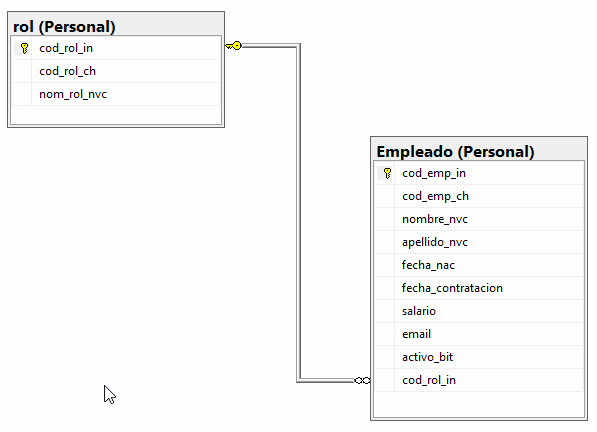



```
USE empresa;
GO
IF EXISTS
(
	SELECT *
	FROM sys.schemas AS s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE
		s.name = 'Personal'
		AND
		t.name = 'Empleado'
)
DROP TABLE Personal.Empleado;
GO
    CREATE TABLE [Personal].[Empleado] (
        cod_emp_in INT IDENTITY(1,1) NOT NULL CONSTRAINT pk_personal_empleado_cod_emp_in PRIMARY KEY CLUSTERED,
        cod_emp_ch VARCHAR(10) NOT NULL CONSTRAINT ak_personal_empleado_cod_emp_ch UNIQUE,
        nombre_nvc NVARCHAR(100) NOT NULL,
        apellido_nvc NVARCHAR(100) NOT NULL,
        fecha_nac DATE NULL,
        fecha_contratacion DATE NOT NULL CONSTRAINT df_personal_empleado_fecha_contratacion DEFAULT (CAST(GETDATE() AS DATE)),
        salario DECIMAL(18,2) NOT NULL CONSTRAINT df_personal_empleado_salario DEFAULT (0.00),
        email VARCHAR(255) NULL,
        activo_bit BIT NOT NULL CONSTRAINT df_personal_empleado_activo DEFAULT (1), -- 1 = activo
        cod_rol_in INT NOT NULL,
        CONSTRAINT fk_personal_empleado_cod_rol_in FOREIGN KEY (cod_rol_in)
            REFERENCES [Personal].[rol] (cod_rol_in)
            ON UPDATE NO ACTION
            ON DELETE NO ACTION
    );
GO
INSERT INTO [Personal].[Empleado] (cod_emp_ch, nombre_nvc, apellido_nvc, fecha_nac, fecha_contratacion, salario, email, activo_bit, cod_rol_in)
VALUES
('E0001', N'Carlos',   N'González',   '1985-04-12', '2020-01-15', 2500.00, 'carlos.gonzalez@example.com', 1, 6), -- Personal
('E0002', N'María',    N'Fernández',  '1990-07-22', '2021-03-01', 2300.00, 'maria.fernandez@example.com', 1, 9), -- Ventas
('E0003', N'Juan',     N'López',      '1982-11-05', '2018-05-20', 2700.00, 'juan.lopez@example.com', 1, 1), -- Almacen
('E0004', N'Ana',      N'Ruiz',       '1995-02-17', '2022-06-10', 2200.00, 'ana.ruiz@example.com', 1, 2), -- Cobranzas
('E0005', N'Luis',     N'Martínez',   '1979-09-30', '2015-09-01', 3200.00, 'luis.martinez@example.com', 1, 7), -- Sistemas
('E0006', N'Laura',    N'Pérez',      '1988-12-11', '2019-11-05', 2400.00, 'laura.perez@example.com', 1, 4), -- Facturación
('E0007', N'Óscar',    N'Morales',    '1992-03-03', '2020-08-21', 2100.00, 'oscar.morales@example.com', 1, 3), -- Compras
('E0008', N'Sofía',    N'Gómez',      '1991-05-14', '2021-12-01', 2000.00, 'sofia.gomez@example.com', 1, 5), -- Pagos
('E0009', N'Iván',     N'Hernández',  '1987-10-09', '2017-04-18', 2600.00, 'ivan.hernandez@example.com', 1, 8), -- Transportes
('E0010', N'Elena',    N'Soto',       '1993-06-27', '2023-02-15', 2150.00, 'elena.soto@example.com', 1, 9); -- Ventas
GO
SELECT * FROM Personal.Empleado;
GO
```





```
USE empresa;
GO
IF EXISTS
(
	SELECT name
	FROM sys.foreign_keys
	WHERE name = 'fk_personal_empleado_cod_rol_in'
)
BEGIN
	ALTER TABLE Personal.Empleado
	DROP CONSTRAINT fk_personal_empleado_cod_rol_in;
END
GO
ALTER TABLE Personal.Empleado
ADD CONSTRAINT fk_personal_empleado_cod_rol_in
FOREIGN KEY (cod_rol_in)
	REFERENCES Personal.rol (cod_rol_in)
	ON UPDATE CASCADE
	ON DELETE NO ACTION;
GO
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Características de la Clave Foránea (FK)</font>**

</td>
</tr>
</table>

>* **Integridad Referencial**: La clave foránea asegura que cada valor en la columna referenciada corresponda a un registro existente en la tabla de referencia. Esto evita que se introduzcan datos "huérfanos" en la tabla secundaria.
>* **Relación entre Tablas**: Las claves foráneas se utilizan para establecer relaciones entre tablas. Por ejemplo, puedes tener una relación de uno a muchos, donde una fila en la tabla principal puede estar relacionada con múltiples filas en la tabla relacionada.
>* **Cascada de Acciones**: Puedes definir acciones en cascada para lo que sucede cuando se actualiza o elimina un registro en la tabla padre. Por ejemplo, puedes especificar que al eliminar un registro en la tabla padre, se eliminen también automáticamente los registros relacionados en la tabla hija.

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">UPDATE</font>**

</td>
</tr>
</table>

La sentencia UPDATE en SQL Server se utiliza para modificar los registros existentes en una tabla.

Esta sentencia permite cambiar uno o más valores en una o varias columnas de una o varias filas que cumplen con una condición específica.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
UPDATE esquema.nombre_tabla
SET columna1 = valor1,
    columna2 = valor2,
    ...
WHERE condiciones;
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Restricción CHECK (CK)</font>**

</td>
</tr>
</table>

La restricción CHECK en SQL Server es una manera de imponer condiciones específicas sobre los valores que pueden ser insertados o actualizados en una columna de una tabla.

Esta restricción asegura que los datos sean válidos y cumplan criterios definidos por el usuario, lo que ayuda a mantener la integridad de los datos.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Características de la Restricción CHECK</font>**

</td>
</tr>
</table>

>* **Condiciones Personalizadas**: Puedes definir condiciones que deben cumplir los valores en una o más columnas. Por ejemplo, asegurarte de que un valor se encuentre dentro de un rango específico.
>* **Verificación Durante Inserciones y Actualizaciones**: La restricción se verifica cada vez que se inserta o actualiza un registro. Si un valor no cumple con la condición especificada, SQL Server generará un error y no permitirá la operación.
>* **Se Puede Aplicar a Múltiples Columnas**: La restricción CHECK puede hacer referencia a una sola columna o a varias columnas en la tabla.

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">El valor por defecto DEFAULT (DF)</font>**

</td>
</tr>
</table>

El valor por defecto, especificado mediante la restricción DEFAULT en SQL Server, permite asignar un valor automático a una columna cuando se insertan nuevos registros.

Si no se proporciona un valor explícito para esa columna durante la inserción, SQL Server utilizará el valor por defecto definido.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Características del Valor por Defecto</font>**

</td>
</tr>
</table>

>* **Especificación Automática**: Cuando se inserta un registro sin proporcionar un valor para la columna que tiene un valor por defecto, SQL Server asigna automáticamente ese valor.
>* **Tipos de Datos**: El valor por defecto puede ser de cualquier tipo de datos que sea compatible con la columna en la que se establece.
>* **Uso Común**: Se utiliza comúnmente para fechas, estados predeterminados, y otros valores que son comunes o estándar para nuevas filas.



```
USE empresa;
GO
ALTER TABLE Personal.Empleado
DROP CONSTRAINT ak_personal_empleado_dni_emp_ch;
GO
ALTER TABLE Personal.Empleado
DROP CONSTRAINT ck_personal_empleado_dni_emp_ch
GO
IF EXISTS
(
	SELECT *
	FROM sys.schemas s
	INNER JOIN sys.tables  t
	ON s.schema_id = t.schema_id
	INNER JOIN sys.columns c
	ON t.object_id = c.object_id
	WHERE
		s.name = 'Personal'
		AND t.name = 'Empleado'
		AND c.name = 'dni_emp_ch'
)
BEGIN
	ALTER TABLE Personal.Empleado
	DROP COLUMN dni_emp_ch;
END;
GO
ALTER TABLE Personal.Empleado
ADD dni_emp_ch td_dni NULL;
GO
ALTER TABLE Personal.Empleado
ADD CONSTRAINT ck_personal_empleado_dni_emp_ch
CHECK (dni_emp_ch LIKE '[0-9][0-9][0-9][0-9][0-9][0-9][0-9][0-9]');
GO
UPDATE Personal.Empleado
SET dni_emp_ch = RIGHT('87654321' + CAST(cod_emp_in AS VARCHAR(8)), 8);
GO
ALTER TABLE Personal.Empleado
ADD CONSTRAINT ak_personal_empleado_dni_emp_ch
UNIQUE (dni_emp_ch);
GO
SELECT * FROM Personal.Empleado;
GO


```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Diferencias entre DELETE y TRUNCATE TABLE</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

#### **<font color="#FFFFFF">DELETE</font>**

</td>
</tr>
</table>



```
USE [empresa]
GO
IF EXISTS
(
	SELECT * FROM sys.schemas  s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE s.name = 'Almacen' AND t.name = 'Categoria'
)
DROP TABLE [Almacen].[Categoria]
GO
CREATE TABLE [Almacen].[Categoria](
	[cod_cat_in] [dbo].[td_codigo] IDENTITY(1,1) NOT NULL,
	[nom_cat_nvc] [dbo].[td_nombre] NOT NULL
)
GO
INSERT INTO [Almacen].[Categoria] (nom_cat_nvc) VALUES ('Electrónica'),
('Ropa'),
('Hogar'),
('Deportes'),
('Juguetes')
GO
SELECT * FROM [Almacen].[Categoria]
GO
DELETE FROM [Almacen].[Categoria]
GO
SELECT * FROM [Almacen].[Categoria]
GO
INSERT INTO [Almacen].[Categoria] (nom_cat_nvc) VALUES ('Televisores')
GO
SELECT * FROM [Almacen].[Categoria]
GO
```



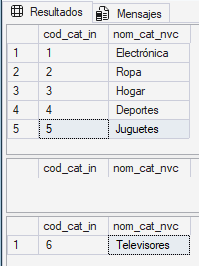



```
USE [empresa]
GO
IF EXISTS
(
	SELECT * FROM sys.schemas  s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE s.name = 'Almacen' AND t.name = 'Categoria'
)
DROP TABLE [Almacen].[Categoria]
GO
CREATE TABLE [Almacen].[Categoria](
	[cod_cat_in] [dbo].[td_codigo] IDENTITY(1,1) NOT NULL,
	[nom_cat_nvc] [dbo].[td_nombre] NOT NULL
)
GO
INSERT INTO [Almacen].[Categoria] (nom_cat_nvc) VALUES ('Electrónica'),
('Ropa'),
('Hogar'),
('Deportes'),
('Juguetes')
GO
SELECT * FROM [Almacen].[Categoria]
GO
DELETE FROM [Almacen].[Categoria]
WHERE cod_cat_in > 3
GO
SELECT * FROM [Almacen].[Categoria]
GO
INSERT INTO [Almacen].[Categoria] (nom_cat_nvc) VALUES ('Televisores')
GO
SELECT * FROM [Almacen].[Categoria]
GO
```



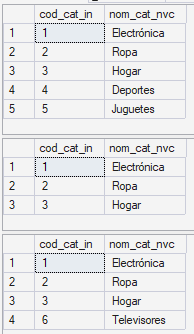

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

#### **<font color="#FFFFFF">TRUNCATE TABLE</font>**

</td>
</tr>
</table>



```
USE [empresa]
GO
IF EXISTS
(
	SELECT * FROM sys.schemas  s
	INNER JOIN sys.tables t
	ON s.schema_id = t.schema_id
	WHERE s.name = 'Almacen' AND t.name = 'Categoria'
)
DROP TABLE [Almacen].[Categoria]
GO
CREATE TABLE [Almacen].[Categoria](
	[cod_cat_in] [dbo].[td_codigo] IDENTITY(1,1) NOT NULL,
	[nom_cat_nvc] [dbo].[td_nombre] NOT NULL
)
GO
INSERT INTO [Almacen].[Categoria] (nom_cat_nvc) VALUES ('Electrónica'),
('Ropa'),
('Hogar'),
('Deportes'),
('Juguetes')
GO
SELECT * FROM [Almacen].[Categoria]
GO
TRUNCATE TABLE [Almacen].[Categoria]
GO
SELECT * FROM [Almacen].[Categoria]
GO
INSERT INTO [Almacen].[Categoria] (nom_cat_nvc) VALUES ('Televisores')
GO
SELECT * FROM [Almacen].[Categoria]
GO
```



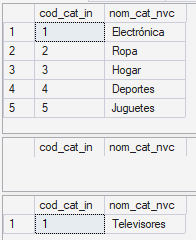

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Ejemplos de Update</font>**

</td>
</tr>
</table>



```
/*
En la base de datos 'empresa', incrementa el sueldo en un 10% a
todos los empleados que cumplen años en el mes junio
y pertenecen al rol de 'Ventas'.
*/
USE empresa;
GO
SELECT *
FROM Personal.Empleado e
INNER JOIN Personal.Rol r
ON e.cod_rol_in = r.cod_rol_in
WHERE
	r.nom_rol_nvc = 'Ventas'
	AND MONTH(e.fecha_nac) = 6;
GO
```





```
/*
En la base de datos 'empresa', incrementa el sueldo en un 10% a
todos los empleados que cumplen años en el mes junio
y pertenecen al rol de 'Ventas'.
*/
USE empresa;
GO
SELECT
	salario,
	salario * 1.1 AS nuevo_salario
FROM Personal.Empleado e
INNER JOIN Personal.Rol r
ON e.cod_rol_in = r.cod_rol_in
WHERE
	r.nom_rol_nvc = 'Ventas'
	AND MONTH(e.fecha_nac) = 6;
GO
```





```
/*
En la base de datos 'empresa', incrementa el sueldo en un 10% a
todos los empleados que cumplen años en el mes junio
y pertenecen al rol de 'Ventas'.
*/
USE empresa;
GO
UPDATE Personal.Empleado
SET salario = salario * 1.1
FROM Personal.Empleado e
INNER JOIN Personal.Rol r
ON e.cod_rol_in = r.cod_rol_in
WHERE
	r.nom_rol_nvc = 'Ventas'
	AND MONTH(e.fecha_nac) = 6;
GO
SELECT salario
FROM Personal.Empleado e
INNER JOIN Personal.Rol r
ON e.cod_rol_in = r.cod_rol_in
WHERE
	r.nom_rol_nvc = 'Ventas'
	AND MONTH(e.fecha_nac) = 6;
GO
```

